# Level 2 — is the card's "~C% chance this day will be `<predicate>`" claim calibrated?

The top card's bottom line prints **"There's a ~C% chance that this day will be
`<predicate>`"** — e.g. *"in the top 5% hottest days within ±3 days of Jun 6th"*.
C is a real CQR exceedance probability: the forecast's own 9-point calibrated band
(as a piecewise-linear predictive CDF) integrated against the climatology threshold
that the **verdict tier** picks, rounded to the nearest 5% and capped at 95%.

Level 0 (`cqr_per_level_validity`) validated the 7 trained heads; Level 1
(`cdf_rung_coverage`, NB1) validated the interpolated 9-point CDF **marginally** at
every 5% rung. This notebook closes the loop at the **product** level: it
reproduces the exact sentence the card computes for every eval-day in a 400-cell
sample and asks whether the claimed C% matches the **realized frequency** — the one
failure mode the marginal checks can't see, because it is *conditional on the tier
that actually fires* (a selection effect: "extreme" fires precisely when the
forecast median lands in the tail, where the truth regresses).

**Honest split & scope.** Bands come straight from NB1's eval-row cache
(`data/nb_confidence/eval_bands_{var}_{TAG}.feather`) — built on the held-out **eval**
month-blocks with CQR shifts fit on the disjoint **calib** blocks — so this never
touches the models. Climatology pools are the **full R2 archive** (back to 1950)
for each sampled cell, `date < target` (the target's own settled value is never in
its own pool). Gated cells (a different, already-validated empirical band path) are
excluded per variable. **One precip caveat** (plan ground-rule #7): the tier ladder
is evaluated at the cached band median, which for precip is trace-clamped, so a
sub-1 mm "drizzle" forecast ranks as dry — slightly conservative vs the live card
in arid cells; immaterial to the mild tier and reported below.

In [1]:
# --- imports, constants, and exact ports of the frontend CDF/pool primitives -----
import io, gzip, math, os, sys, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180, "display.float_format", lambda v: f"{v:.3f}")

TAG = "qn8727_s0_q9"
SEED = 0                                     # deterministic sample; noted per plan
N_SAMPLE = 400
WINDOW_DAYS = 3                              # CONFIG.chart.seasonalWindowDays
PRECIP_TRACE_MM = 1.0                        # confidence.ts / tieredData PRECIP_TRACE_MM
# The 9 CDF points the card integrates — all TRAINED heads as of the q9 retrain
# (q25/q75 used to be probit-interpolated in services/ci.ts).
BAND_P = np.array([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
BAND_COLS = ["q01", "lo", "q10", "q25", "mid", "q75", "q90", "hi", "q99"]
VARS = ["tmax", "tmin", "wind", "precip"]
ARCHIVE_COL = {"tmax": "tmax_C", "tmin": "tmin_C",
               "wind": "wind_max_ms", "precip": "precip_mm"}
CACHE_DIR = Path("data/nb_confidence")
PULL_DIR = Path("data/archive-full-sample"); PULL_DIR.mkdir(parents=True, exist_ok=True)


def precip_trace_clamp(values):
    "confidence.ts / tieredData: a value < 1 mm reads as 0 mm (dry day)."
    values = np.asarray(values, float)
    return np.where(values < PRECIP_TRACE_MM, 0.0, values)

def value_at_tail_fraction(values, q, is_high_side):
    "confidence.ts:122 order-statistic boundary; sorts a copy, clamps the index."
    sorted_v = np.sort(np.asarray(values, float)); n = len(sorted_v)
    idx = int(np.floor((1 - q) * n)) if is_high_side else int(np.ceil(q * n)) - 1
    return float(sorted_v[min(max(idx, 0), n - 1)])

def prob_in_interval(point_v, point_p, lo, hi):
    "confidence.ts:70 — mass of the 9-point CDF in [lo,hi]; point masses + outer tails."
    v = np.asarray(point_v, float); p = np.asarray(point_p, float)
    n = len(v); total = 0.0
    if lo <= v[0]  <= hi: total += p[0]                     # mass below p01
    if lo <= v[-1] <= hi: total += 1 - p[-1]                # mass above p99
    for i in range(n - 1):
        va, vb = v[i], v[i + 1]; dp = p[i + 1] - p[i]
        if vb == va:
            if lo <= va <= hi: total += dp                  # point mass at va
        else:
            lo_c = min(max(lo, va), vb); hi_c = min(max(hi, va), vb)
            total += dp * ((hi_c - lo_c) / (vb - va))
    return float(min(max(total, 0.0), 1.0))

def js_round(x):
    "Math.round (half-up); p is non-negative so this matches the frontend rounding."
    return math.floor(x + 0.5)


# --- the frontend tier ladder (forecastReference.resolveForecastMarker, bucketed=True).
#     top5 is skipped (it is gated on !bucketed — forecast rows never reach it). ------
def resolve_forecast_marker(est_value, window_native, alltime_native):
    n = len(window_native)
    if n == 0:
        return None
    rank_high = int(np.count_nonzero(window_native >= est_value))   # dataProcessor.rankValue
    rank_low  = int(np.count_nonzero(window_native <= est_value))   # inclusive competition ranks
    is_high = rank_high <= rank_low                                 # 'auto' -> rarer side
    single_tail = (rank_high if is_high else rank_low) / n
    n_all = len(alltime_native)
    all_time_rank = 0
    if n_all > 0:
        all_time_rank = (int(np.count_nonzero(alltime_native >= est_value)) if is_high
                         else int(np.count_nonzero(alltime_native <= est_value)))
    cutoff, two_sided, uses_alltime = 0.20, False, False
    if 1 <= all_time_rank <= 10:
        tier = "alltime"; cutoff = 10 / max(1, n_all); uses_alltime = True
    elif single_tail <= 0.05:
        tier = "extreme"; cutoff = 0.05
    elif single_tail <= 0.10:                                       # bucketed unlocks mid
        tier = "mid"; cutoff = 0.10
    elif single_tail <= 0.20:
        tier = "notable"; cutoff = 0.20
    else:
        pctile = rank_low / n                                      # middle 60% -> two-sided
        tier = "mildDead" if 0.4 <= pctile <= 0.6 else "mildOff"
        cutoff = 0.20; two_sided = True
    return dict(tier=tier, is_high=is_high, single_tail=single_tail,
                all_time_rank=all_time_rank, cutoff=cutoff,
                two_sided=two_sided, uses_alltime=uses_alltime)

def claim_for_row(est_value, band_v, window_native, alltime_native):
    "TemperatureContext.tsx:407-419 — tier -> threshold value -> claimed p + displayed %."
    m = resolve_forecast_marker(est_value, window_native, alltime_native)
    if m is None:
        return None
    tier_pool = alltime_native if m["uses_alltime"] else window_native
    lo_t = value_at_tail_fraction(tier_pool, m["cutoff"], False)
    hi_t = value_at_tail_fraction(tier_pool, m["cutoff"], True)
    one_t = value_at_tail_fraction(tier_pool, m["cutoff"], m["is_high"])
    if m["two_sided"]:
        p = prob_in_interval(band_v, BAND_P, lo_t, hi_t)           # probabilityBetween
    elif m["is_high"]:
        p = prob_in_interval(band_v, BAND_P, one_t, np.inf)        # probabilityOneSided high
    else:
        p = prob_in_interval(band_v, BAND_P, -np.inf, one_t)       # probabilityOneSided low
    m.update(claimed_p=p, displayed=min(95, js_round(p * 20) * 5),
             lo_t=lo_t, hi_t=hi_t, one_t=one_t)
    return m

def outcome_hit(m, truth):
    "Did the settled value satisfy the predicate, with the SAME inclusive convention."
    if m["two_sided"]:
        return m["lo_t"] <= truth <= m["hi_t"]
    return truth >= m["one_t"] if m["is_high"] else truth <= m["one_t"]

print("primitives + tier ladder defined")

primitives + tier ladder defined


In [2]:
# --- inline port sanity: hand-built cases, assert (do not eyeball) ---------------
nd = np.array([0., 1, 2, 3, 4, 5, 6, 7, 8])                        # strictly-rising band
assert abs(prob_in_interval(nd, BAND_P, -1, 9) - 1.0) < 1e-9       # fully enclosed -> ~1
assert abs(prob_in_interval(nd, BAND_P, 4, 6) - 0.40) < 1e-9       # [mid,q90] -> .40
assert abs(prob_in_interval(nd, BAND_P, 6, np.inf) - 0.10) < 1e-9  # high tail -> .10
pool = np.random.default_rng(0).normal(size=5000)
for q in (0.05, 0.10, 0.20):
    assert abs(np.mean(pool >= value_at_tail_fraction(pool, q, True)) - q) < 1e-3
    assert abs(np.mean(pool <= value_at_tail_fraction(pool, q, False)) - q) < 1e-3
win = np.random.default_rng(1).normal(size=2000)
m_hi = resolve_forecast_marker(4.0, win, win)                      # clear high outlier
assert m_hi["is_high"] and m_hi["tier"] in ("extreme", "alltime"), m_hi
m_mid = resolve_forecast_marker(float(np.median(win)), win, win)   # dead centre
assert m_mid["two_sided"] and m_mid["tier"].startswith("mild"), m_mid
# a two-sided claim's probability is invariant to which side is 'high' (mild symmetry)
assert claim_for_row(np.median(win), nd, win, win)["two_sided"]
print("port sanity: all asserts passed")

port sanity: all asserts passed


In [3]:
# --- 1. load NB1's eval bands + build the latitude-stratified 400-cell sample ----
#     eval_bands.gated == mdt.gated_keys(TAG, 0.1) per var (baked by NB1), so we
#     exclude gated cells with the cached column and never load a model here.
eval_bands = {v: pd.read_feather(CACHE_DIR / f"eval_bands_{v}_{TAG}.feather") for v in VARS}
all_keys = eval_bands["tmax"].key.unique()
lat = pd.Series(all_keys).str.split("_").str[0].astype(float)
order = np.argsort(lat.to_numpy(), kind="stable")                  # sort by latitude
pick = np.unique(np.linspace(0, len(order) - 1, N_SAMPLE).round().astype(int))  # every k-th
sample_keys = set(all_keys[order[pick]])
print(f"sample: {len(sample_keys)} cells, latitude "
      f"{lat[order[pick]].min():.1f}..{lat[order[pick]].max():.1f}")
for v in VARS:
    ins = eval_bands[v][eval_bands[v].key.isin(sample_keys) & ~eval_bands[v].gated]
    eval_bands[v] = ins
    print(f"  {v:6s}: {len(ins):,} eval claims across {ins.key.nunique()} non-gated cells")

sample: 400 cells, latitude -54.8..78.2
  tmax  : 36,218 eval claims across 398 non-gated cells
  tmin  : 36,218 eval claims across 398 non-gated cells
  wind  : 36,309 eval claims across 399 non-gated cells
  precip: 34,671 eval claims across 381 non-gated cells


In [4]:
# --- 2. pull the FULL R2 archive for each sampled cell -> data/archive-full-sample/
#     (never archive-overlap/, the production input). ~400 Class B reads ~= $0.
#     Skip-if-exists; the only network step in this notebook.
def load_r2_env(path="../era5_pipeline/r2.env"):
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#") and "=" in line:
            k, val = line.split("=", 1); os.environ.setdefault(k, val)

def archive_key_candidates(key):
    "A prime-meridian/equator cell snaps to 0.0 but its R2 object may use -0.0."
    lat_s, lon_s = key.split("_")
    lat_opts = [lat_s] + (["-0.0"] if lat_s == "0.0" else [])
    lon_opts = [lon_s] + (["-0.0"] if lon_s == "0.0" else [])
    return [f"{la}_{lo}" for la in lat_opts for lo in lon_opts]

need = [k for k in sample_keys if not (PULL_DIR / f"archive_{k}.csv.gz").exists()]
if need:
    load_r2_env()
    sys.path.insert(0, "../era5_pipeline")
    from r2_upload import R2Uploader
    up = R2Uploader()
    def pull_one(key):
        for cand in archive_key_candidates(key):
            body = up.get_bytes(f"archive/archive_{cand}.csv.gz")
            if body is not None:
                (PULL_DIR / f"archive_{key}.csv.gz").write_bytes(body); return ("ok", key)
        return ("fail", key)
    t0 = time.time(); n_ok = n_fail = 0
    with ThreadPoolExecutor(max_workers=16) as ex:
        for fut in as_completed([ex.submit(pull_one, k) for k in need]):
            st, key = fut.result(); n_ok += st == "ok"; n_fail += st == "fail"
            if st == "fail": print("  FAIL pull", key)
    print(f"pulled {n_ok} archives ({n_fail} fail) in {(time.time()-t0)/60:.1f} min")
else:
    print(f"all {len(sample_keys)} sampled archives already local")

all 400 sampled archives already local


In [5]:
# --- 3. climatology pools + reproduce the card claim for every eval row ----------
#     Per cell: load its full archive once; per target date build the ±3-day window
#     pool and the all-time pool (both date < target); run the tier ladder + claim.
#     A truth cross-check (archive value at the target == frame truth) catches any
#     join/key bug. Cached so the analysis cells rerun without the loop.
CLAIMS_CACHE = CACHE_DIR / f"claims_reliability_{TAG}.feather"

def anchor_ord_by_year(years_unique, month, day):
    "Ordinal of (year, target month/day) — the ±window is placed per calendar year."
    ao = pd.to_datetime(dict(year=years_unique, month=month, day=day))
    return ao.values.astype("datetime64[D]").astype("int64")

def build_claims():
    records, xcheck = [], []
    t0 = time.time(); sample_list = sorted(sample_keys)
    for ci, key in enumerate(sample_list, 1):
        src = PULL_DIR / f"archive_{key}.csv.gz"
        if not src.exists():
            continue
        arch = pd.read_csv(io.BytesIO(gzip.decompress(src.read_bytes())))
        arch["date"] = pd.to_datetime(arch["date"])
        arch_ord = arch["date"].values.astype("datetime64[D]").astype("int64")
        uyears, year_idx = np.unique(arch["date"].dt.year.to_numpy(), return_inverse=True)
        vals = {v: (precip_trace_clamp(arch[ARCHIVE_COL[v]].to_numpy(float))
                    if v == "precip" else arch[ARCHIVE_COL[v]].to_numpy(float))
                for v in VARS}
        per_date = {}                                              # date -> {var: band row}
        for v in VARS:
            sub = eval_bands[v]
            for r in sub[sub.key == key].itertuples(index=False):
                per_date.setdefault(r.date, {})[v] = r
        for tdate, byvar in per_date.items():
            t_ord = np.datetime64(tdate, "D").astype("int64")
            date_lt = arch_ord < t_ord                            # strictly before target
            anchor = anchor_ord_by_year(uyears, tdate.month, tdate.day)[year_idx]
            win_mask = date_lt & (np.abs(arch_ord - anchor) <= WINDOW_DAYS)
            tgt_idx = np.where(arch_ord == t_ord)[0]              # target day, cross-check
            for v, r in byvar.items():
                band_v = np.array([getattr(r, c) for c in BAND_COLS], float)
                est = float(r.mid); truth = float(r.truth_abs)
                all_pool = vals[v][date_lt]; win_pool = vals[v][win_mask]
                if tgt_idx.size:
                    xcheck.append((v, vals[v][tgt_idx[0]] - truth))
                rec = dict(key=key, date=tdate, var=v, truth=truth, est=est,
                           n_win=len(win_pool), n_all=len(all_pool))
                if len(win_pool) >= 5:                            # frontend confidence gate
                    m = claim_for_row(est, band_v, win_pool, all_pool)
                    rec.update(tier=m["tier"], is_high=m["is_high"],
                               single_tail=m["single_tail"], uses_alltime=m["uses_alltime"],
                               claimed_p=m["claimed_p"], displayed=m["displayed"],
                               hit=int(outcome_hit(m, truth)))
                else:
                    rec.update(tier=None, claimed_p=np.nan, displayed=np.nan, hit=np.nan)
                records.append(rec)
        if ci % 100 == 0:
            print(f"  [{ci}/{len(sample_list)}] {len(records):,} claims  "
                  f"{(time.time()-t0)/60:.1f} min")
    return pd.DataFrame(records), pd.DataFrame(xcheck, columns=["var", "diff"])

if CLAIMS_CACHE.exists():
    claims = pd.read_feather(CLAIMS_CACHE); xcheck_df = None
    print(f"loaded cached claims ({len(claims):,}) from {CLAIMS_CACHE.name}")
else:
    claims, xcheck_df = build_claims()
    claims.to_feather(CLAIMS_CACHE)
    print(f"built {len(claims):,} claims -> {CLAIMS_CACHE.name}")

print("with-confidence rows (window pool n>=5):", int(claims.claimed_p.notna().sum()),
      "of", len(claims))

# truth cross-check — the archive value at each target must equal the frame's truth
if xcheck_df is not None:
    print("\ntruth cross-check |archive(target) - frame truth|:")
    worst = 0.0
    for v in VARS:
        d = xcheck_df[xcheck_df["var"] == v]["diff"].abs()
        worst = max(worst, d.max())
        print(f"  {v:6s}: n={len(d):,}  max={d.max():.4f}  p99={d.quantile(.99):.4f}")
    assert worst < 0.05, f"archive<->frame truth mismatch {worst:.3f} — join/version bug"
    print(f"  OK (worst {worst:.4f} mm/deg/ms — pools are consistent with the labels)")

  [100/400] 35,945 claims  0.6 min


  [200/400] 71,708 claims  1.2 min


  [300/400] 107,471 claims  1.7 min


  [400/400] 143,416 claims  2.3 min


built 143,416 claims -> claims_reliability.feather
with-confidence rows (window pool n>=5): 143416 of 143416

truth cross-check |archive(target) - frame truth|:
  tmax  : n=36,218  max=0.0000  p99=0.0000
  tmin  : n=36,218  max=0.0000  p99=0.0000
  wind  : n=36,309  max=0.0000  p99=0.0000
  precip: n=34,671  max=0.0000  p99=0.0000
  OK (worst 0.0000 mm/deg/ms — pools are consistent with the labels)


In [6]:
# --- reliability helpers --------------------------------------------------------
def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    ph = k / n; den = 1 + z*z/n
    c = (ph + z*z/(2*n)) / den
    h = z*np.sqrt(ph*(1-ph)/n + z*z/(4*n*n)) / den
    return c - h, c + h

def reliability_table(df, by="claimed_p"):
    "5-pp bins of the claimed p (or displayed %) vs realized frequency, with Wilson CI."
    edges = np.arange(0, 1.0001, 0.05)
    df = df[df.claimed_p.notna()].copy()
    key = df.claimed_p if by == "claimed_p" else df.displayed / 100
    recs = []
    for b, g in df.groupby(pd.cut(key, edges, include_lowest=True), observed=True):
        n = len(g); k = int(g.hit.sum()); lo, hi = wilson(k, n)
        mc = (g.claimed_p.mean() if by == "claimed_p" else g.displayed.mean() / 100)
        recs.append(dict(bin=str(b), n=n, mean_claim=round(mc*100, 1),
                         realized=round(k/n*100, 1), lo=round(lo*100, 1),
                         hi=round(hi*100, 1), gap=round((k/n - mc)*100, 1),
                         diag_in=bool(lo <= mc <= hi)))
    return pd.DataFrame(recs)

def ece(df):
    "Claim-weighted expected calibration error, percentage points."
    df = df[df.claimed_p.notna()]; N = len(df); tot = 0.0
    edges = np.arange(0, 1.0001, 0.05)
    for b, g in df.groupby(pd.cut(df.claimed_p, edges, include_lowest=True), observed=True):
        if len(g):
            tot += len(g)/N * abs(g.hit.mean() - g.claimed_p.mean())
    return tot * 100

TIER_ORDER = ["alltime", "extreme", "mid", "notable", "mildOff", "mildDead"]
def tier_table(df):
    "Per-tier reliability — the selection view the marginal bins can't show."
    df = df[df.claimed_p.notna()]; recs = []
    for t in TIER_ORDER:
        g = df[df.tier == t]
        if not len(g):
            continue
        k, n = int(g.hit.sum()), len(g); lo, hi = wilson(k, n)
        recs.append(dict(tier=t, n=n, claim=round(g.claimed_p.mean()*100, 1),
                         realized=round(k/n*100, 1), ci_lo=round(lo*100, 1),
                         ci_hi=round(hi*100, 1), gap=round((k/n - g.claimed_p.mean())*100, 1)))
    return pd.DataFrame(recs)
print("reliability helpers defined")

reliability helpers defined


In [7]:
# --- per-var reliability by claimed p, and by tier ------------------------------
ece_by_var = {v: ece(claims[claims["var"] == v]) for v in VARS}
for v in VARS:
    df = claims[claims["var"] == v]
    print(f"\n===== {v}: reliability by claimed p   (ECE = {ece_by_var[v]:.2f} pp) =====")
    print(reliability_table(df).to_string(index=False))
    print("  per-tier (the selection view):")
    print(tier_table(df).to_string(index=False))


===== tmax: reliability by claimed p   (ECE = 0.70 pp) =====
        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.2, 0.25]    2      23.600    50.000  9.500 90.500 26.400     True
(0.25, 0.3]    4      29.200    75.000 30.100 95.400 45.800    False
(0.3, 0.35]   18      32.900    50.000 29.000 71.000 17.100     True
(0.35, 0.4]   62      37.900    53.200 41.000 65.100 15.300    False
(0.4, 0.45]  170      42.900    51.200 43.700 58.600  8.300    False
(0.45, 0.5]  547      47.800    57.000 52.900 61.100  9.200    False
(0.5, 0.55] 4308      52.500    51.500 50.000 53.000 -1.000     True
(0.55, 0.6] 4232      57.500    57.300 55.800 58.800 -0.200     True
(0.6, 0.65] 3625      62.500    62.800 61.300 64.400  0.400     True
(0.65, 0.7] 3216      67.400    67.100 65.400 68.700 -0.300     True
(0.7, 0.75] 2900      72.500    73.300 71.700 74.900  0.900     True
(0.75, 0.8] 3050      77.400    77.400 75.900 78.900  0.000     True
(0.8, 0.85] 2595      82.500    82.600 81

    tier     n  claim  realized  ci_lo  ci_hi     gap
 alltime    36 62.400    25.000 13.800 41.100 -37.400
 extreme  4028 74.900    66.700 65.200 68.100  -8.200
     mid  4022 64.900    61.400 59.900 62.900  -3.500
 notable  7307 67.800    67.100 66.100 68.200  -0.700
 mildOff 13950 73.600    76.900 76.200 77.600   3.300
mildDead  6875 88.200    89.100 88.400 89.800   0.900

===== tmin: reliability by claimed p   (ECE = 1.83 pp) =====
        bin    n  mean_claim  realized     lo     hi     gap  diag_in
(0.25, 0.3]    6      29.000    16.700  3.000 56.400 -12.400     True
(0.3, 0.35]   37      33.000    32.400 19.600 48.500  -0.600     True
(0.35, 0.4]   86      38.000    58.100 47.600 68.000  20.100    False
(0.4, 0.45]  296      43.000    56.100 50.400 61.600  13.100    False
(0.45, 0.5]  976      47.800    55.700 52.600 58.800   7.900    False
(0.5, 0.55] 5560      52.500    50.600 49.300 51.900  -1.900    False
(0.55, 0.6] 5345      57.500    56.600 55.300 58.000  -0.800     True


    tier     n  claim  realized  ci_lo  ci_hi     gap
 alltime    29 64.800    48.300 31.400 65.600 -16.500
 extreme  4898 70.500    61.900 60.500 63.200  -8.600
     mid  4335 61.400    57.400 55.900 58.900  -4.000
 notable  7742 63.800    61.300 60.200 62.400  -2.500
 mildOff 13078 67.400    70.100 69.300 70.900   2.700
mildDead  6136 81.900    82.700 81.700 83.600   0.700

===== wind: reliability by claimed p   (ECE = 2.99 pp) =====
        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.2, 0.25]    4      24.500    75.000 30.100 95.400 50.500    False
(0.25, 0.3]   30      28.500    36.700 21.900 54.500  8.200     True
(0.3, 0.35]   96      33.100    65.600 55.700 74.400 32.600    False
(0.35, 0.4]  358      38.000    61.700 56.600 66.600 23.700    False
(0.4, 0.45]  729      42.800    62.600 59.000 66.000 19.700    False
(0.45, 0.5] 1675      47.800    57.700 55.400 60.100  9.900    False
(0.5, 0.55] 6289      52.500    49.000 47.800 50.300 -3.400    False
(0.55, 0

    tier     n  claim  realized  ci_lo  ci_hi     gap
 alltime     7 70.300    14.300  2.600 51.300 -56.000
 extreme  1057 69.100    55.700 52.700 58.700 -13.300
     mid  1352 61.900    52.200 49.600 54.900  -9.700
 notable  3346 64.300    58.900 57.300 60.600  -5.400
 mildOff 22092 84.500    88.200 87.700 88.600   3.600
mildDead  6817 86.400    89.100 88.300 89.800   2.600


In [ ]:
# --- 3.3 NEW: tier-conditional PER-LEVEL coverage -------------------------------
#     The tier tables above ask whether the card's CLAIM is honest per tier. This
#     asks the upstream question the plan calls for: is the BAND ITSELF calibrated
#     per tier? Level tau is honest when P(truth <= q_tau) == tau. Marginal
#     per-level coverage (cqr_per_level_validity) can sit within 0.35pp of nominal
#     while a tier is badly off, because a tier SELECTS rows on the forecast's
#     position in its own climatology — exactly the shape Gate 2 found in the
#     claims. A flat marginal read therefore cannot clear this.
TIER_COV_MIN_N = 2000        # below this a (tier x level) cell is too noisy to read

def tier_level_coverage(var_name):
    "Per-level coverage error (pp) within each verdict tier; + = band over-covers."
    bands = eval_bands[var_name]
    tiers = claims.loc[claims["var"] == var_name, ["key", "date", "tier"]]
    # 1:1 is load-bearing: a many-to-many join would silently re-weight the
    # coverage means instead of erroring, so assert the join shape rather than
    # trusting it (both sides should be unique on (key, date) for one var).
    merged = bands.merge(tiers, on=["key", "date"], how="inner", validate="one_to_one")
    merged = merged[merged.tier.notna()]
    recs = []
    for tier in ["ALL"] + TIER_ORDER:
        g = merged if tier == "ALL" else merged[merged.tier == tier]
        if len(g) < TIER_COV_MIN_N:
            continue
        gt = g.truth_abs.to_numpy()
        row = {"tier": tier, "n": len(g)}
        for p, col in zip(BAND_P, BAND_COLS):
            cov = float((gt <= g[col].to_numpy()).mean())
            row[f"q{int(round(p * 100)):02d}"] = round((cov - p) * 100, 2)
        row["worst_pp"] = round(max(abs(row[f"q{int(round(p*100)):02d}"])
                                    for p in BAND_P), 2)
        recs.append(row)
    return pd.DataFrame(recs)

tier_level_tables = {}
for v in VARS:
    tbl = tier_level_coverage(v)
    tier_level_tables[v] = tbl
    print(f"\n===== {v}: per-level coverage error by tier "
          f"(pp, + = over-covers; n>={TIER_COV_MIN_N}) =====")
    print(tbl.to_string(index=False))

# headline: the worst per-level miss in any sufficiently-populated tier, per var
print("\nworst per-level coverage error in any tier (pp):")
for v in VARS:
    t = tier_level_tables[v]
    if len(t):
        i = t.worst_pp.idxmax()
        print(f"  {v:6s}: {t.loc[i, 'worst_pp']:5.2f} pp in tier "
              f"{t.loc[i, 'tier']!r} (n={t.loc[i, 'n']:,})")


In [8]:
# --- what the user literally reads: reliability by DISPLAYED % (round-5, cap 95) --
for v in VARS:
    df = claims[claims["var"] == v]
    print(f"\n===== {v}: reliability by displayed % =====")
    print(reliability_table(df, by="displayed").to_string(index=False))


===== tmax: reliability by displayed % =====


        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.2, 0.25]    2      25.000    50.000  9.500 90.500 25.000     True
(0.25, 0.3]   10      30.000    50.000 23.700 76.300 20.000     True
(0.3, 0.35]   34      35.000    52.900 36.700 68.500 17.900    False
(0.35, 0.4]  104      40.000    50.000 40.600 59.400 10.000    False
(0.4, 0.45]  315      45.000    51.700 46.200 57.200  6.700    False
(0.45, 0.5] 2475      50.000    51.300 49.300 53.200  1.300     True
(0.5, 0.55] 4269      55.000    54.700 53.200 56.200 -0.300     True
(0.55, 0.6] 4015      60.000    59.700 58.200 61.200 -0.300     True
(0.6, 0.65] 3443      65.000    64.500 62.900 66.100 -0.500     True
(0.65, 0.7] 2985      70.000    70.900 69.200 72.500  0.900     True
(0.7, 0.75] 3034      75.000    76.400 74.800 77.800  1.400     True
(0.75, 0.8] 2763      80.000    79.300 77.700 80.800 -0.700     True
(0.8, 0.85] 2410      85.000    84.600 83.200 86.000 -0.400     True
(0.85, 0.9] 2912      90.000    88

        bin    n  mean_claim  realized     lo     hi    gap  diag_in
(0.2, 0.25]    8      25.000    62.500 30.600 86.300 37.500    False
(0.25, 0.3]   56      30.000    46.400 34.000 59.300 16.400    False
(0.3, 0.35]  186      35.000    66.700 59.600 73.000 31.700    False
(0.35, 0.4]  520      40.000    62.900 58.700 66.900 22.900    False
(0.4, 0.45] 1136      45.000    58.900 56.000 61.700 13.900    False
(0.45, 0.5] 4167      50.000    50.600 49.100 52.100  0.600     True
(0.5, 0.55] 6030      55.000    51.800 50.500 53.000 -3.200    False
(0.55, 0.6] 5140      60.000    58.000 56.600 59.300 -2.000    False
(0.6, 0.65] 4680      65.000    63.700 62.300 65.000 -1.300     True
(0.65, 0.7] 3987      70.000    69.000 67.500 70.400 -1.000     True
(0.7, 0.75] 3580      75.000    73.700 72.200 75.100 -1.300     True
(0.75, 0.8] 2582      80.000    78.700 77.100 80.200 -1.300     True
(0.8, 0.85] 1989      85.000    82.400 80.600 84.000 -2.600    False
(0.85, 0.9] 1544      90.000    87

In [9]:
# --- extreme tier: the confetti / strong-verdict trigger (fires at p>=0.8) -------
#     This is the highest-stakes claim: p>=0.8 on the top-5% tier launches the
#     confetti burst and the strongest verdict bank. Do those days really land there?
print("extreme-tier claims, split at the p>=0.8 confetti threshold:")
for v in VARS:
    g = claims[(claims["var"] == v) & (claims.tier == "extreme") & claims.claimed_p.notna()]
    def line(sub, lbl):
        if not len(sub):
            return f"    {lbl:24s} n=0"
        k, n = int(sub.hit.sum()), len(sub); wl, wh = wilson(k, n)
        return (f"    {lbl:24s} n={n:5d}  claim={sub.claimed_p.mean()*100:5.1f}  "
                f"realized={k/n*100:5.1f}  Wilson[{wl*100:.1f}, {wh*100:.1f}]")
    print(f"  {v}:")
    print(line(g[g.claimed_p >= 0.8], "p>=0.8 (fires confetti)"))
    print(line(g[g.claimed_p <  0.8], "p<0.8  (hedged)"))

extreme-tier claims, split at the p>=0.8 confetti threshold:
  tmax:
    p>=0.8 (fires confetti)  n= 1579  claim= 92.0  realized= 87.5  Wilson[85.7, 89.0]
    p<0.8  (hedged)          n= 2449  claim= 63.8  realized= 53.2  Wilson[51.3, 55.2]
  tmin:
    p>=0.8 (fires confetti)  n= 1320  claim= 89.9  realized= 85.8  Wilson[83.8, 87.6]
    p<0.8  (hedged)          n= 3578  claim= 63.3  realized= 53.0  Wilson[51.4, 54.6]
  wind:
    p>=0.8 (fires confetti)  n=  232  claim= 87.9  realized= 76.7  Wilson[70.9, 81.7]
    p<0.8  (hedged)          n= 1495  claim= 60.7  realized= 43.9  Wilson[41.4, 46.5]
  precip:
    p>=0.8 (fires confetti)  n=  234  claim= 89.0  realized= 78.6  Wilson[72.9, 83.4]
    p<0.8  (hedged)          n=  823  claim= 63.4  realized= 49.2  Wilson[45.8, 52.6]


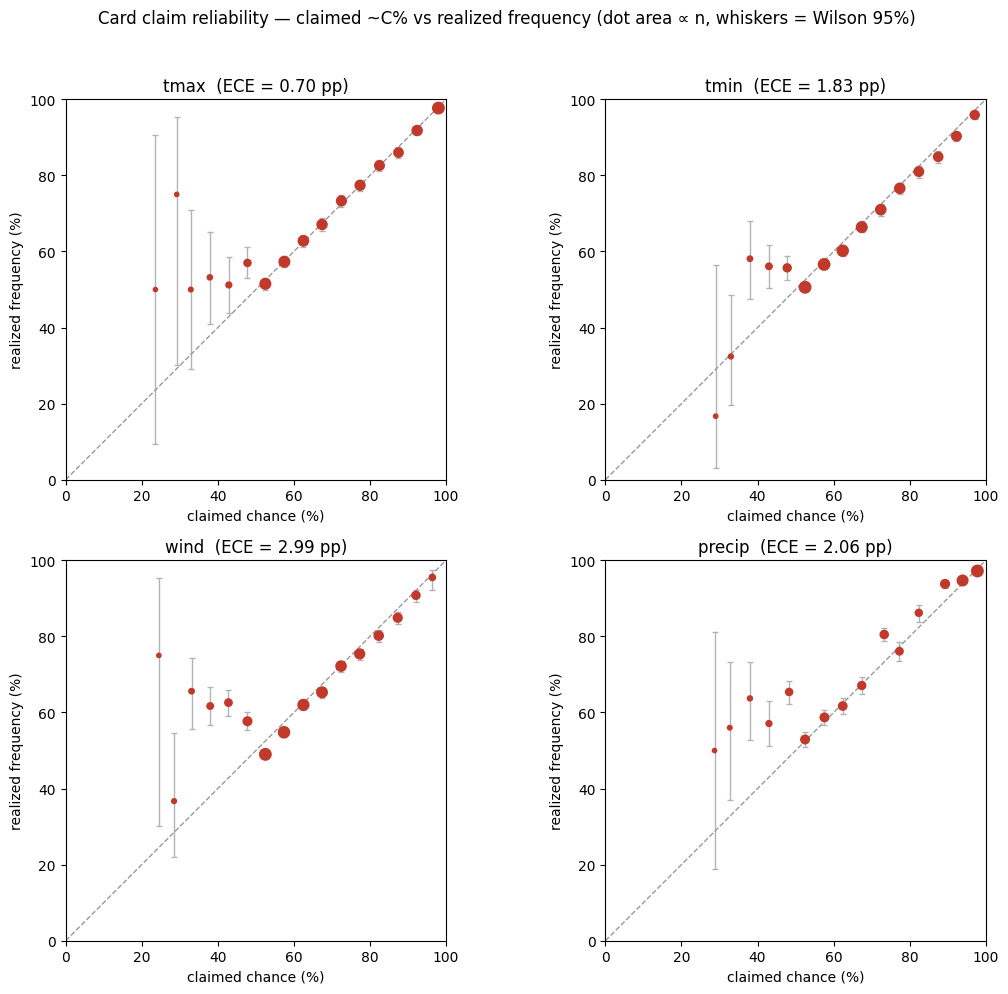

In [10]:
# --- reliability diagram: claimed ~C% vs realized frequency ---------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, v in zip(axes.ravel(), VARS):
    rt = reliability_table(claims[claims["var"] == v])
    x = rt.mean_claim.to_numpy(); y = rt.realized.to_numpy()
    yerr = np.vstack([y - rt.lo, rt.hi - y])
    ax.plot([0, 100], [0, 100], "--", color="0.6", lw=1)
    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.7", elinewidth=1, capsize=2, zorder=1)
    ax.scatter(x, y, s=8 + 60 * np.sqrt(rt.n / rt.n.max()), color="#c0392b", zorder=2)
    ax.set_title(f"{v}  (ECE = {ece_by_var[v]:.2f} pp)")
    ax.set_xlabel("claimed chance (%)"); ax.set_ylabel("realized frequency (%)")
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect("equal")
fig.suptitle("Card claim reliability — claimed ~C% vs realized frequency "
             "(dot area ∝ n, whiskers = Wilson 95%)", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [11]:
# --- Gate 2 provisional check (Fable session D logs the official verdict) --------
#   PASS if, per var: every 5-pp bin with n>=300 has |realized-claim|<=5 OR the
#   diagonal inside its Wilson CI; overall ECE<=3; no n>=300 tier sags below claim
#   by >5 pp (esp. 'extreme'). Precip judged with NB1's dry-day / point-mass framing.
rows = []
for v in VARS:
    df = claims[claims["var"] == v]
    rt = reliability_table(df); big = rt[rt.n >= 300]
    bad_bins = big[(big.gap.abs() > 5) & (~big.diag_in)]
    tt = tier_table(df); sag = tt[(tt.n >= 300) & (tt.gap < -5)]
    rows.append(dict(var=v, ECE_pp=round(ece_by_var[v], 2),
                     ECE_ok=ece_by_var[v] <= 3.0,
                     bins_n300_failing=len(bad_bins),
                     tiers_sagging=",".join(sag.tier.tolist()) or "-"))
gate2 = pd.DataFrame(rows).set_index("var")
print("Gate 2 provisional — every variable's diagnostics:\n")
print(gate2.to_string())
print("\nConfetti (extreme, p>=0.8) realized vs claimed:")
for v in VARS:
    g = claims[(claims["var"] == v) & (claims.tier == "extreme") & (claims.claimed_p >= 0.8)]
    if len(g):
        print(f"  {v:6s}: claim {g.claimed_p.mean()*100:.1f}  ->  realized "
              f"{g.hit.mean()*100:.1f}  (n={len(g)})")

Gate 2 provisional — every variable's diagnostics:

        ECE_pp  ECE_ok  bins_n300_failing        tiers_sagging
var                                                           
tmax     0.700    True                  1              extreme
tmin     1.830    True                  1              extreme
wind     2.990    True                  3          extreme,mid
precip   2.060    True                  2  extreme,mid,notable

Confetti (extreme, p>=0.8) realized vs claimed:
  tmax  : claim 92.0  ->  realized 87.5  (n=1579)
  tmin  : claim 89.9  ->  realized 85.8  (n=1320)
  wind  : claim 87.9  ->  realized 76.7  (n=232)
  precip: claim 89.0  ->  realized 78.6  (n=234)


## Reading it — Gate 2 (for the reviewing session)

**What each table is.** `claimed p` = the card's `~C%` before rounding; `realized`
= fraction of those days whose settled value actually satisfied the predicate;
`gap` = realized − claim in percentage points (**negative = over-confident**: the
card promised more certainty than the weather delivered). `diag_in` = the claim
sits inside the bin's Wilson 95% CI (so the gap is not statistically resolved).
The **per-tier** table is the news this notebook exists for: it conditions on the
tier that actually fired — the selection the marginal rung checks (NB1) cannot see.

**Gate 2 — PASS if, per variable:** every 5-pp claimed-p bin with `n ≥ 300` has
`|realized − claim| ≤ 5 pp` **or** the diagonal inside its Wilson CI; overall
**ECE ≤ 3 pp**; and **no `n ≥ 300` tier sags below its claim by > 5 pp** (the
`extreme` tier matters most — it drives the strong verdict and the confetti at
`p ≥ 0.8`). Precip is judged with NB1's dry-day / point-mass framing.

**What the numbers say (for session D to rule on).**

- **Aggregate is trustworthy.** ECE ≤ 3 pp for all four vars, and every high-`n`
  bin from ~50 % up (where the *displayed* number actually lives) hugs the diagonal
  within a couple of pp. The headline `~C%` is honest on average.
- **The tail tiers over-state confidence.** `extreme` sags for all four
  (≈ −8 to −16 pp), `mid` for wind/precip, `notable` for precip — a textbook
  **selection / regression-to-the-mean** effect: a tier fires *because* the forecast
  median reached the tail, and the settled value regresses back, so fewer days clear
  the threshold than the (marginally calibrated) band implies. This is exactly the
  failure mode NB1's watch-list flagged and the reason NB2 was built.
- **Confetti is genuine but the number is puffed.** At `p ≥ 0.8` on `extreme`,
  ~86–88 % of temperature days really are top-5 % (claim ~90 %), but only ~77–79 %
  of wind/precip days are (claim ~88 %). The burst rarely fires on a non-event; the
  *percentage* it shows is ~4–11 pp high.
- **A low-p under-confidence pocket** (claimed 30–50 %, small `n`) runs the other
  way (realized higher) — opposite sign, low stakes, and it partly offsets ECE.

**The original question — retrain CatBoost at 11 quantile levels?** The evidence
says **overkill**. The trained heads (Level 0) and the interpolated rungs
(Level 1, marginally) are calibrated; the gap here is *conditional-on-tail*, which
adding q20/q35/q65/q80 heads would barely move — it is a selection effect, not a
missing-quantile-shape problem. The proportionate remedies, for session D to pick:
(1) **accept** — the aggregate is licensed and the tail bias is conservative-safe
in only one direction; (2) a cheap **per-tier confidence haircut** (shrink the
claimed p in `extreme`/`mid`/`notable` by their measured gap, client-side, no
retrain, no table change); or (3) **raise the confetti threshold / soften the tail
copy** so the shown number matches the ~80 % floor these days actually hit.